# Method comparison (UNI vs UNI, MULTI vs MULTI)

Цель: сравнение методов **как в** `benchmark_exp/comparison_PCA_Chronos2Fast.ipynb`, но:
- автоматом по всем CSV в `eval/metrics/uni/*.csv` и `eval/metrics/multi/*.csv`
- сравнения делаются **только внутри одной группы** (`uni` с `uni`, `multi` с `multi`)
- более "софистикейтед":
  - сводки mean/median/quantiles
  - попарные сравнения на пересечении файлов (wins / ties / mean delta / bootstrap CI)
  - sign-test p-value (exact binomial, без scipy)
  - срезы по `dataset_family` (например `UCR/YAHOO/MITDB` из имени `file`)
  - per-file таблицы (какой метод лучший/худший на каждом `file`)


In [15]:
import os

os.chdir("/workspace/skoltech/tsfm-2026")

print(os.getcwd())

/workspace/skoltech/tsfm-2026


In [16]:
from __future__ import annotations

import math
import re
from dataclasses import dataclass
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

ROOT = Path.cwd()
EVAL_METRICS_DIR = ROOT / "eval" / "metrics"
assert EVAL_METRICS_DIR.exists(), f"Missing: {EVAL_METRICS_DIR}"

UNI_DIR = EVAL_METRICS_DIR / "uni"
MULTI_DIR = EVAL_METRICS_DIR / "multi"
assert UNI_DIR.exists(), f"Missing: {UNI_DIR}"
assert MULTI_DIR.exists(), f"Missing: {MULTI_DIR}"


## 1) Load all runs (CSV) + parse run metadata

In [17]:
@dataclass(frozen=True)
class RunMeta:
    scope: str  # uni|multi
    method: str
    timestamp: str | None
    tag: str | None
    run_path: str


_RUN_RE = re.compile(r"^(?P<method>.+?)_(?P<ts>\d{8}-\d{6})(?:_(?P<tag>.+?))?\.csv$")


def parse_run_meta(path: Path) -> RunMeta:
    scope = path.parent.name  # uni/multi
    m = _RUN_RE.match(path.name)
    if not m:
        return RunMeta(scope=scope, method=path.stem, timestamp=None, tag=None, run_path=str(path.relative_to(ROOT)))
    return RunMeta(
        scope=scope,
        method=m.group("method"),
        timestamp=m.group("ts"),
        tag=m.group("tag"),
        run_path=str(path.relative_to(ROOT)),
    )


def extract_dataset_family(file_name: str) -> str | None:
    # Example: 806_YAHOO_id_256_Synthetic_tr_500_1st_893.csv -> YAHOO
    stem = Path(str(file_name)).stem
    parts = stem.split("_")
    if len(parts) < 2:
        return None
    fam = parts[1].strip()
    return fam or None


def load_run(path: Path) -> pd.DataFrame:
    meta = parse_run_meta(path)
    df = pd.read_csv(path)
    df.insert(0, "run_path", meta.run_path)
    df.insert(1, "scope", meta.scope)
    df.insert(2, "method", meta.method)
    df.insert(3, "timestamp", meta.timestamp)
    df.insert(4, "tag", meta.tag)
    if "file" not in df.columns:
        raise ValueError(f"Expected column 'file' in {meta.run_path}")
    df["dataset_family"] = df["file"].astype(str).map(extract_dataset_family)
    return df


csv_paths = sorted(list(UNI_DIR.glob("*.csv")) + list(MULTI_DIR.glob("*.csv")))
print("Runs (CSVs):", len(csv_paths))
display(pd.DataFrame({"run_path": [str(p.relative_to(ROOT)) for p in csv_paths]}))

raw = pd.concat([load_run(p) for p in csv_paths], ignore_index=True)

meta_cols = {"run_path", "scope", "method", "timestamp", "tag", "file", "dataset_family"}
metric_cols = [c for c in raw.columns if c not in meta_cols][1:]

# numeric coercion
for c in metric_cols:
    raw[c] = pd.to_numeric(raw[c], errors="coerce")

print("Rows:", raw.shape)
print("Metric columns:", metric_cols)
raw.head(3)

Runs (CSVs): 11


,run_path
0,eval/metrics/multi/Chronos2FastPredictMax_2026...
1,eval/metrics/multi/Chronos2FastPredictMean_202...
2,eval/metrics/multi/Chronos2FastPredictMean_202...
3,eval/metrics/multi/Chronos2FastPredictMean_202...
4,eval/metrics/multi/IForest_20260512-085956_bot...
5,eval/metrics/uni/Chronos2FastPredict_20260511-...
6,eval/metrics/uni/Chronos2Fast_20260511-190657_...
7,eval/metrics/uni/Chronos2Fast_20260511-192407_...
8,eval/metrics/uni/Chronos2Fast_20260511-193846_...
9,eval/metrics/uni/Chronos2Fast_20260512-151348_...


Rows: (1245, 28)
Metric columns: ['AUC-PR', 'AUC-ROC', 'VUS-PR', 'VUS-ROC', 'Standard-F1', 'PA-F1', 'Event-based-F1', 'R-based-F1', 'Affiliation-F', 'ECE', 'F1', 'ROC-AUC', 'MCE', 'Adaptive-ECE', 'Brier', 'NLL', 'Sharpness-Std', 'ErrDet-AUROC', 'AURC', 'EAURC']


,run_path,scope,method,timestamp,tag,file,Time,AUC-PR,AUC-ROC,VUS-PR,VUS-ROC,Standard-F1,PA-F1,Event-based-F1,R-based-F1,Affiliation-F,ECE,dataset_family,F1,ROC-AUC,MCE,Adaptive-ECE,Brier,NLL,Sharpness-Std,ErrDet-AUROC,AURC,EAURC
0,eval/metrics/multi/Chronos2FastPredictMax_2026...,multi,Chronos2FastPredictMax,20260511-232232,both,019_MITDB_id_1_Medical_tr_37500_1st_103211.csv,36.572663,0.145347,0.553083,0.145593,0.554085,0.224247,1.000000,1.000000,0.333453,0.979917,0.119802,MITDB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,eval/metrics/multi/Chronos2FastPredictMax_2026...,multi,Chronos2FastPredictMax,20260511-232232,both,020_MITDB_id_2_Medical_tr_50000_1st_52315.csv,132.378611,0.006162,0.560597,0.002711,0.590187,0.013983,0.999046,0.833333,0.289514,0.944840,0.001400,MITDB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,eval/metrics/multi/Chronos2FastPredictMax_2026...,multi,Chronos2FastPredictMax,20260511-232232,both,021_MITDB_id_3_Medical_tr_50000_1st_57595.csv,102.169045,0.015501,0.451248,0.018591,0.512744,0.034653,0.823560,0.034639,0.029728,0.674031,0.017889,MITDB,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
metric_cols

['AUC-PR',
 'AUC-ROC',
 'VUS-PR',
 'VUS-ROC',
 'Standard-F1',
 'PA-F1',
 'Event-based-F1',
 'R-based-F1',
 'Affiliation-F',
 'ECE',
 'F1',
 'ROC-AUC',
 'MCE',
 'Adaptive-ECE',
 'Brier',
 'NLL',
 'Sharpness-Std',
 'ErrDet-AUROC',
 'AURC',
 'EAURC']

## 2) Global summary per run (mean/median/quantiles)

In [20]:
def summarize_runs(df: pd.DataFrame, metrics: list[str]) -> pd.DataFrame:
    def q(s: pd.Series, p: float) -> float:
        return float(s.quantile(p))

    agg = {
        "n_files": (metrics[0], "count"),
    }

    # build as named aggregations
    named = {}
    for m in metrics:
        named[f"{m}__mean"] = (m, "mean")
        #named[f"{m}__median"] = (m, "median")
        #named[f"{m}__q25"] = (m, lambda s, p=0.25: q(s, p))
        #named[f"{m}__q75"] = (m, lambda s, p=0.75: q(s, p))


    out = (
        df.groupby(["scope", "method", "timestamp", "tag", "run_path"], dropna=False)
        .agg(**{"n_files": ("file", "count")}, **named)
        .reset_index()
    )
    return out


run_summary = summarize_runs(raw, metric_cols)
run_summary.sort_values(["scope", "method", "timestamp"], na_position="last").head(50)

,scope,method,timestamp,tag,run_path,n_files,AUC-PR__mean,AUC-ROC__mean,VUS-PR__mean,VUS-ROC__mean,Standard-F1__mean,PA-F1__mean,Event-based-F1__mean,R-based-F1__mean,Affiliation-F__mean,ECE__mean,F1__mean,ROC-AUC__mean,MCE__mean,Adaptive-ECE__mean,Brier__mean,NLL__mean,Sharpness-Std__mean,ErrDet-AUROC__mean,AURC__mean,EAURC__mean
0,multi,Chronos2FastPredictMax,20260511-232232,both,eval/metrics/multi/Chronos2FastPredictMax_2026...,40,0.337845,0.716888,0.338079,0.733086,0.346355,0.947368,0.772989,0.269857,0.914706,0.074936,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,multi,Chronos2FastPredictMean,20260511-215843,both,eval/metrics/multi/Chronos2FastPredictMean_202...,36,0.401170,0.747434,0.401009,0.760956,0.401220,0.945613,0.821478,0.280767,0.925106,0.080514,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,multi,Chronos2FastPredictMean,20260512-152309,NaN,eval/metrics/multi/Chronos2FastPredictMean_202...,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.059852,0.120487,0.557123,0.500403,0.060378,0.062314,0.464925,0.017116,0.556242,0.055267,0.051250
3,multi,Chronos2FastPredictMean,20260512-153229,NaN,eval/metrics/multi/Chronos2FastPredictMean_202...,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.073621,0.361395,0.729747,0.761444,0.073296,0.073593,0.714704,0.014751,0.730715,0.046450,0.042568
4,multi,IForest,20260512-085956,both,eval/metrics/multi/IForest_20260512-085956_bot...,40,0.225923,0.746939,0.230872,0.760325,0.320289,0.820586,0.505233,0.318319,0.863874,0.192036,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,uni,Chronos2Fast,20260511-190657,no_seq,eval/metrics/uni/Chronos2Fast_20260511-190657_...,163,0.651859,0.946659,0.819648,0.946435,0.806576,0.804534,0.804534,0.831524,0.958506,0.006000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,uni,Chronos2Fast,20260511-192407,no_seq,eval/metrics/uni/Chronos2Fast_20260511-192407_...,163,0.651859,0.946659,0.819648,0.946435,0.806576,0.804534,0.804534,0.831524,0.958506,0.006000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,uni,Chronos2Fast,20260511-193846,with_seq,eval/metrics/uni/Chronos2Fast_20260511-193846_...,218,0.049037,0.563960,0.038284,0.647053,0.073112,0.612723,0.257285,0.119382,0.842210,0.010938,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,uni,Chronos2Fast,20260512-151348,no_seq,eval/metrics/uni/Chronos2Fast_20260512-151348_...,163,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.006000,0.806576,0.946659,0.803619,0.004722,0.002385,0.032447,0.047982,0.712973,0.002669,0.002660
9,uni,Chronos2Fast,20260512-151552,with_seq,eval/metrics/uni/Chronos2Fast_20260512-151552_...,218,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010938,0.073112,0.563960,0.895498,0.013770,0.008080,0.057700,0.035182,0.627926,0.006278,0.006212


## 3) Pairwise comparison (within scope)

Попарное сравнение двух методов на пересечении `file`.

Вывод:
- wins/ties
- mean/median delta
- bootstrap CI для mean delta
- sign-test p-value (exact binomial)
- топ файлов по абсолютной разнице


In [10]:
def sign_test_p_value(wins: int, losses: int) -> float:
    """Two-sided exact binomial sign test p-value, H0: p=0.5.
    Ties should be removed before calling.
    """
    n = wins + losses
    if n == 0:
        return float("nan")
    k = min(wins, losses)
    # p = 2 * P(X <= k) where X ~ Bin(n, 0.5)
    p = 0.0
    for i in range(0, k + 1):
        p += math.comb(n, i) * (0.5 ** n)
    return min(1.0, 2.0 * p)


def bootstrap_mean_ci(deltas: np.ndarray, iters: int = 5000, seed: int = 0) -> tuple[float, float]:
    if len(deltas) == 0:
        return (float("nan"), float("nan"))
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(deltas), size=(iters, len(deltas)))
    means = deltas[idx].mean(axis=1)
    lo, hi = np.quantile(means, [0.025, 0.975])
    return float(lo), float(hi)


def pairwise_compare(
    df: pd.DataFrame,
    scope: str,
    run_path_a: str,
    run_path_b: str,
    metric: str,
    top_k_files: int = 20,
) -> dict[str, object]:
    dd = df[df["scope"] == scope]
    a = dd[dd["run_path"] == run_path_a][["file", metric]].rename(columns={metric: "a"})
    b = dd[dd["run_path"] == run_path_b][["file", metric]].rename(columns={metric: "b"})
    merged = a.merge(b, on="file", how="inner")
    merged = merged.dropna(subset=["a", "b"]).copy()
    merged["delta"] = merged["a"] - merged["b"]

    wins = int((merged["delta"] > 0).sum())
    losses = int((merged["delta"] < 0).sum())
    ties = int((merged["delta"] == 0).sum())

    # sign test ignores ties
    p_sign = sign_test_p_value(wins=wins, losses=losses)

    deltas = merged["delta"].to_numpy()
    mean_delta = float(np.mean(deltas)) if len(deltas) else float("nan")
    median_delta = float(np.median(deltas)) if len(deltas) else float("nan")
    ci_lo, ci_hi = bootstrap_mean_ci(deltas)

    hardest = merged.reindex(merged["delta"].abs().sort_values(ascending=False).index).head(top_k_files)

    summary = pd.DataFrame(
        {
            "scope": [scope],
            "metric": [metric],
            "run_a": [run_path_a],
            "run_b": [run_path_b],
            "n_common_files": [len(merged)],
            "wins_a": [wins],
            "wins_b": [losses],
            "ties": [ties],
            "mean_delta(a-b)": [mean_delta],
            "median_delta(a-b)": [median_delta],
            "mean_delta_ci95_lo": [ci_lo],
            "mean_delta_ci95_hi": [ci_hi],
            "sign_test_p": [p_sign],
        }
    )

    return {"summary": summary, "per_file": merged.sort_values("delta", ascending=False), "hardest": hardest}


# Helpers: list run_path within a scope
def list_runs(scope: str) -> pd.DataFrame:
    dd = run_summary[run_summary["scope"] == scope].copy()
    cols = ["method", "timestamp", "tag", "n_files", "run_path"]
    cols = [c for c in cols if c in dd.columns]
    return dd[cols].sort_values(["method", "timestamp"], na_position="last")


#display(list_runs("uni"))
list_runs("multi")
#display(list_runs("multi"))


,method,timestamp,tag,n_files,run_path
0,Chronos2FastPredictMax,20260511-232232,both,40,eval/metrics/multi/Chronos2FastPredictMax_2026...
1,Chronos2FastPredictMean,20260511-215843,both,36,eval/metrics/multi/Chronos2FastPredictMean_202...
2,Chronos2FastPredictMean,20260512-152309,NaN,2,eval/metrics/multi/Chronos2FastPredictMean_202...
3,IForest,20260512-085956,both,40,eval/metrics/multi/IForest_20260512-085956_bot...


,scope,metric,run_a,run_b,n_common_files,wins_a,wins_b,ties,mean_delta(a-b),median_delta(a-b),mean_delta_ci95_lo,mean_delta_ci95_hi,sign_test_p
0,multi,AUC-PR,eval/metrics/multi/IForest_20260512-085956_bot...,eval/metrics/multi/Chronos2FastPredictMax_2026...,40,14,26,0,-0.111922,-0.096988,-0.195519,-0.015405,0.08069


,file,a,b,delta
14,175_Exathlon_id_2_Facility_tr_10684_1st_10784.csv,0.931424,0.059636,0.871787
32,193_Exathlon_id_20_Facility_tr_8898_1st_8998.csv,0.862000,0.083097,0.778904
13,174_Exathlon_id_1_Facility_tr_10766_1st_12590.csv,0.099455,0.543277,-0.443822
19,180_Exathlon_id_7_Facility_tr_10766_1st_12590.csv,0.187909,0.587203,-0.399294
15,176_Exathlon_id_3_Facility_tr_10766_1st_12590.csv,0.187909,0.587203,-0.399294
25,186_Exathlon_id_13_Facility_tr_10766_1st_12590...,0.187909,0.587203,-0.399294
34,195_Exathlon_id_22_Facility_tr_10766_1st_12590...,0.187909,0.587203,-0.399294
21,182_Exathlon_id_9_Facility_tr_10766_1st_12590.csv,0.187909,0.587203,-0.399294
39,200_Exathlon_id_27_Facility_tr_10766_1st_12590...,0.187909,0.587203,-0.399294
36,197_Exathlon_id_24_Facility_tr_10766_1st_12590...,0.187909,0.587203,-0.399294


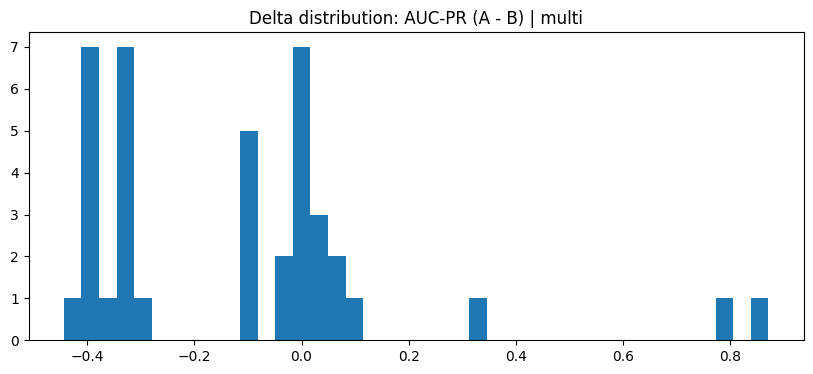

In [11]:
# Choose two runs inside ONE scope and compare them
scope = "multi"  # "uni" or "multi"
metric = "AUC-PR"

# Example: edit these
run_a = "eval/metrics/multi/IForest_20260512-085956_both.csv"
run_b = "eval/metrics/multi/Chronos2FastPredictMax_20260511-232232_both.csv"

res = pairwise_compare(raw, scope=scope, run_path_a=run_a, run_path_b=run_b, metric=metric)
display(res["summary"])
display(res["hardest"].head(30))

# Optional plot of deltas
plt.figure(figsize=(10, 4))
if sns is not None:
    sns.histplot(res["per_file"], x="delta", bins=40)
else:
    plt.hist(res["per_file"]["delta"], bins=40)
plt.title(f"Delta distribution: {metric} (A - B) | {scope}")
plt.show()

## 4) Multi-method comparison within a scope

Сравнение нескольких run'ов внутри `uni` или `multi`:
- mean metric per run
- average rank across files (lower = better)
- per-file winner table (argmax)


In [12]:
def scope_pivot(df: pd.DataFrame, scope: str, metric: str) -> pd.DataFrame:
    dd = df[df["scope"] == scope].copy()
    dd["run"] = dd.apply(lambda r: f"{r['method']}|{r['timestamp']}|{r['tag']}".rstrip("|"), axis=1)
    pv = dd.pivot_table(index="file", columns="run", values=metric, aggfunc="mean")
    return pv


def multi_method_summary(df: pd.DataFrame, scope: str, metric: str) -> dict[str, object]:
    pv = scope_pivot(df, scope=scope, metric=metric)
    mean_per_run = pv.mean(axis=0).sort_values(ascending=False)
    rank_per_file = pv.rank(axis=1, ascending=False, method="average")
    avg_rank = rank_per_file.mean(axis=0).sort_values()  # lower is better
    winner = pv.idxmax(axis=1)
    winner_counts = winner.value_counts(dropna=True)
    out = {
        "pivot": pv,
        "mean_per_run": mean_per_run,
        "avg_rank": avg_rank,
        "winner_counts": winner_counts,
        "per_file_winner": winner.to_frame("winner_run"),
    }
    return out


scope = "uni"
metric = "AUC-PR"
mm = multi_method_summary(raw, scope=scope, metric=metric)

display(mm["mean_per_run"].to_frame("mean"))
display(mm["avg_rank"].to_frame("avg_rank"))
display(mm["winner_counts"].to_frame("n_files_won"))
mm["per_file_winner"].head(20)

,mean
run,
Chronos2Fast|20260511-190657|no_seq,0.651859
Chronos2Fast|20260511-192407|no_seq,0.651859
Chronos2FastPredict|20260511-193617|no_seq,0.651051
Chronos2Fast|20260511-193846|with_seq,0.049037


,avg_rank
run,
Chronos2Fast|20260511-193846|with_seq,1.00000
Chronos2Fast|20260511-190657|no_seq,1.96319
Chronos2Fast|20260511-192407|no_seq,1.96319
Chronos2FastPredict|20260511-193617|no_seq,2.07362


,n_files_won
Chronos2Fast|20260511-193846|with_seq,218
Chronos2FastPredict|20260511-193617|no_seq,142
Chronos2Fast|20260511-190657|no_seq,21


,winner_run
file,
303_UCR_id_1_Medical_tr_2499_1st_8000.csv,Chronos2Fast|20260511-193846|with_seq
304_UCR_id_2_Medical_tr_2499_1st_7000.csv,Chronos2Fast|20260511-193846|with_seq
305_UCR_id_3_Medical_tr_3000_1st_5948.csv,Chronos2Fast|20260511-193846|with_seq
307_UCR_id_5_Facility_tr_29895_1st_39240.csv,Chronos2Fast|20260511-193846|with_seq
308_UCR_id_6_Facility_tr_20000_1st_56600.csv,Chronos2Fast|20260511-193846|with_seq
309_UCR_id_7_Medical_tr_3000_1st_5948.csv,Chronos2Fast|20260511-193846|with_seq
310_UCR_id_8_HumanActivity_tr_2631_1st_8285.csv,Chronos2Fast|20260511-193846|with_seq
311_UCR_id_9_HumanActivity_tr_16000_1st_38400.csv,Chronos2Fast|20260511-193846|with_seq
312_UCR_id_10_Facility_tr_19948_1st_52000.csv,Chronos2Fast|20260511-193846|with_seq


## 5) Dataset-family slices within a scope

Срезы качества по `dataset_family` (из `file`).


In [ ]:
def family_leaderboard(df: pd.DataFrame, scope: str, metric: str) -> pd.DataFrame:
    dd = df[df["scope"] == scope].copy()
    dd["run"] = dd.apply(lambda r: f"{r['method']}|{r['timestamp']}|{r['tag']}".rstrip("|"), axis=1)
    out = (
        dd.groupby(["dataset_family", "run"], dropna=False)[metric]
        .mean()
        .reset_index()
        .sort_values(["dataset_family", metric], ascending=[True, False], na_position="last")
    )
    return out


scope = "uni"
metric = "AUC-PR"
fam = family_leaderboard(raw, scope=scope, metric=metric)
display(fam.head(50))

if sns is not None:
    plt.figure(figsize=(12, 5))
    sns.catplot(data=fam, x="dataset_family", y=metric, hue="run", kind="box", height=5, aspect=2)
    plt.show()

## 6) Per-file comparison table across all runs in a scope

Для каждого `file` показывает значения метрики по run'ам и победителя.


In [ ]:
scope = "multi"
metric = "AUC-PR"

pv = scope_pivot(raw, scope=scope, metric=metric)
winner = pv.idxmax(axis=1)
table = pv.copy()
table.insert(0, "winner", winner)
display(table.head(30))

# Files with biggest spread across runs
spread = (pv.max(axis=1) - pv.min(axis=1)).sort_values(ascending=False)
display(spread.head(30).to_frame("spread"))

## 7) Time vs quality (within scope)

Scatter `Time` vs metric, coloured by run.


In [ ]:
def time_vs_metric(df: pd.DataFrame, scope: str, metric: str):
    dd = df[df["scope"] == scope].copy()
    dd["run"] = dd.apply(lambda r: f"{r['method']}|{r['timestamp']}|{r['tag']}".rstrip("|"), axis=1)
    dd = dd.dropna(subset=["Time", metric])
    plt.figure(figsize=(10, 5))
    if sns is not None:
        sns.scatterplot(data=dd, x="Time", y=metric, hue="run", alpha=0.7, s=18)
    else:
        for run, sub in dd.groupby("run", dropna=False):
            plt.scatter(sub["Time"], sub[metric], alpha=0.7, s=18, label=run)
    plt.xscale("log")
    plt.title(f"{scope}: Time vs {metric}")
    plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.show()


time_vs_metric(raw, scope="uni", metric="AUC-PR")
time_vs_metric(raw, scope="multi", metric="AUC-PR")